# 52-Week High Pullback — Mean Reversion Strategy

## Deployed Configuration: R2 v2

This notebook is the **final, clean backtest** for the 52-week high pullback
mean reversion strategy using the R2 Trend Stack regime gate.

| Parameter | Value |
|-----------|-------|
| Entry depth | >= 40% below 52-week high |
| Quality filters | F2 (no freefall), F3 (not below 200MA) |
| Regime gate | R2 Trend Stack (SPY + IJH + IJR, >= 2/3 above 200SMA) |
| Exit target | within 25% of 52-week high |
| Stop-loss | -25% from entry price |
| Max hold | 63 trading days |
| Max positions | 5 concurrent |
| Cooldown | 20 days any exit, 30 days after stop-loss |
| Sizing | Pullback-weighted |
| Budget | $10,000 |


In [1]:
# Step 1: Setup
import os, sys, warnings
sys.path.insert(0, os.path.abspath('../../../src'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.6,
    'font.size': 10,
})

UNIVERSE_FILE    = '../../../universe.csv'
HIGH_LOOKBACK    = 252    # 52-week high lookback (trading days)
MAX_HOLD_DAYS    = 63     # ~3 months max hold
REBAL_FREQ       = 5      # days between entry scans
TRANSACTION_COST = 0.001  # 0.1% per-side
BT_CAPITAL       = 10_000

print('Setup complete.')


Setup complete.


## Step 2: Load Universe & Download Data


In [2]:
# Step 2: Download data (6y for full warmup coverage)
universe_df = pd.read_csv(UNIVERSE_FILE)
ALL_TICKERS = universe_df['Symbol'].tolist()
print(f'Universe: {len(ALL_TICKERS)} stocks')

download_tickers = list(set(ALL_TICKERS)) + ['SPY', 'IJH', 'IJR']
print(f'Downloading {len(download_tickers)} tickers (6y)...  Takes 3-5 minutes.')

raw = yf.download(
    download_tickers,
    period='6y',
    auto_adjust=True,
    progress=False,
    threads=True,
)

# Extract closes
if isinstance(raw.columns, pd.MultiIndex):
    close_raw = raw['Close']
else:
    close_raw = raw

closes_lt = close_raw[ALL_TICKERS].dropna(axis=1, how='all')
spy_lt    = close_raw['SPY'].dropna()

# 52-week high and pullback matrices
high_lt = closes_lt.rolling(HIGH_LOOKBACK, min_periods=HIGH_LOOKBACK).max()
pb_lt   = (high_lt - closes_lt) / high_lt.replace(0, np.nan)

def _safe_px(row, sym, default=float('nan')):
    try:
        v = row[sym]
        return float(v) if pd.notna(v) else default
    except (KeyError, TypeError):
        return default

print(f'Loaded: {closes_lt.shape[0]} days x {closes_lt.shape[1]} stocks')
print(f'Range : {closes_lt.index[0].date()} to {closes_lt.index[-1].date()}')


Universe: 1392 stocks


$ALEX: possibly delisted; no price data found  (period=6y) (Yahoo error = "No data found, symbol may be delisted")


$HOLX: possibly delisted; no price data found  (period=6y) (Yahoo error = "No data found, symbol may be delisted")


$VRE: possibly delisted; no price data found  (period=6y) (Yahoo error = "No data found, symbol may be delisted")


$MODG: possibly delisted; no price data found  (period=6y) (Yahoo error = "No data found, symbol may be delisted")


...

$CSGS: possibly delisted; no price data found  (period=6y) (Yahoo error = "No data found, symbol may be delisted")



461 Failed downloads:


['ALEX', 'HOLX', 'VRE', 'MODG', 'AL', 'ATGE', 'ASGN', 'HI', 'SEE', 'BK', 'TPH', 'CSGS']: possibly delisted; no price data found  (period=6y) (Yahoo error = "No data found, symbol may be delisted")


['CUZ', 'TDS', 'FAF', 'CTRE', 'MLM', 'YETI', 'BANC', 'PI', 'SIGI', 'FBK', 'BANR', 'CNO', 'KDP', 'CARR', 'ROG', 'ABM', 'WSFS', 'TNL', 'PTGX', 'DTM', 'EAT', 'CSL', 'FBNC', 'UBER', 'STZ', 'LZB', 'GIII', 'IQV', 'EMN', 'BLFS', 'KLIC', 'CFR', 'FUL', 'SMPL', 'CART', 'AMZN', 'NVST', 'SPNT', 'G', 'CME', 'WHR', 'GIS', 'TTC', 'CDP', 'AVY', 'VSCO', 'MIDD', 'MNST', 'CON', 'WOR', 'TGTX', 'BXP', 'AIZ', 'VNOM', 'HD', 'FDX', 'CG', 'BSY', 'LMAT', 'APLS', 'MUSA', 'AES', 'PAHC', 'NMIH', 'LRCX', 'MIR', 'IP', 'HRB', 'MTN', 'LDOS', 'SLAB', 'PPC', 'GWW', 'COHR', 'FBIN', 'DNOW', 'ISRG', 'CLH', 'BAH', 'EQT', 'FN', 'ROK', 'ARCB', 'NSA', 'SPY', 'FE', 'QNST', 'DVN', 'HAS', 'GMED', 'UNFI', 'IVZ', 'TFX', 'MKC', 'FRT', 'EVR', 'MOS', 'NEOG', 'UBSI', 'MTB', 'WGO', 'DVAX', 'CTAS', 'NWN', 'FWRD', 'EFC', 'AVT', 'SXT', 'OTTR', 'REGN', 'PCRX', 'FIBK', 'DOCS', 'SIG', 'BC', 'CFG', 'CLSK', 'PSKY', 'KRYS', 'HXL', 'TGT', 'WRLD', 'ESI', 'KR', 'DLTR', 'GDDY', 'NRG', 'REXR', 'AEO', 'BRBR', 'LBRT', 'FCFS', 'TNDM', 'AAT', 'PRGO', 'AF

Loaded: 1507 days x 934 stocks
Range : 2020-08-05 to 2026-08-05


## Step 3: Quality Filters & R2 Regime Gate


In [3]:
# Step 3: Quality filters
# F2: price >= 50% of 52w high (not in freefall)
_f2 = (closes_lt >= 0.5 * high_lt).fillna(False)

# F3: price >= 90% of 200-day MA (not structurally broken)
_ma200 = closes_lt.rolling(200, min_periods=100).mean()
_f3 = (closes_lt >= 0.9 * _ma200).fillna(False)

print('Quality filters ready: _f2 (no freefall), _f3 (above 200MA)')

# R2 Trend Stack gate: SPY + IJH + IJR above their 200-day SMA
_regime_tickers = ['SPY', 'IJH', 'IJR']
_regime_sma200  = {
    tk: close_raw[tk].dropna().rolling(200, min_periods=100).mean()
    for tk in _regime_tickers if tk in close_raw.columns
}
_r2_count = sum(
    (close_raw[tk].dropna() > _regime_sma200[tk]).reindex(closes_lt.index).fillna(False)
    for tk in _regime_tickers if tk in _regime_sma200
)
R2_GATE = (_r2_count >= 2)
print(f'R2 gate ON: {R2_GATE.sum()} / {len(R2_GATE)} days ({R2_GATE.sum()/len(R2_GATE)*100:.0f}%)')


Quality filters ready: _f2 (no freefall), _f3 (above 200MA)
R2 gate ON: 0 / 1507 days (0%)


## Step 4: Backtest Engines


In [4]:
# ── Step 14A: Backtest engine with entry-stop + CB + regime + vol sizing ─────
def backtest_lt_risk(
    closes, high_52w, pullback,
    entry_mask,
    exit_pullback=0.25,
    stop_from_high=0.80,
    stop_from_entry=None,          # NEW: e.g. 0.30 means sell if -30% from entry
    trailing_stop=None,            # NEW: e.g. 0.25 means 25% trail from post-entry peak
    initial_capital=100_000,
    top_n=20,
    rebal_freq=5,
    max_hold_days=MAX_HOLD_DAYS,
    tc=TRANSACTION_COST,
    max_portfolio_dd=None,         # NEW: portfolio circuit breaker for new entries
    regime_gate=None,              # NEW: pd.Series bool indexed by date
    vol_weighted_entries=False,    # NEW: inverse-vol weighting across new entries
    vol20=None,                    # pd.DataFrame annualized vol
):
    dates     = closes.index
    start_idx = HIGH_LOOKBACK + 5

    capital   = initial_capital
    positions = {}
    port_vals, port_dates, trade_log = [], [], []
    port_peak = initial_capital

    for i, date in enumerate(dates[start_idx:], start=start_idx):
        prices = closes.iloc[i]

        # ── Exits ──────────────────────────────────────────────────────────────
        to_exit = []
        for sym, pos in positions.items():
            px = _safe_px(prices, sym, np.nan)
            if np.isnan(px) or px <= 0:
                to_exit.append((sym, "delisted")); continue

            days_held = i - pos["entry_idx"]
            cur_high  = _safe_px(high_52w.iloc[i], sym, pos["ref_high"])
            cur_pb    = (cur_high - px) / cur_high if cur_high > 0 else 1.0

            # Track running peak since entry for trailing stop
            pos["peak_price"] = max(pos.get("peak_price", pos["entry_price"]), px)

            reason = None
            if cur_pb <= exit_pullback:
                reason = "target"
            elif stop_from_entry is not None and px <= pos["entry_price"] * (1 - stop_from_entry):
                reason = "stop_entry"
            elif trailing_stop is not None and px <= pos["peak_price"] * (1 - trailing_stop):
                reason = "stop_trail"
            elif cur_pb >= stop_from_high:
                reason = "stop_high"
            elif days_held >= max_hold_days:
                reason = "timeout"

            if reason:
                to_exit.append((sym, reason))

        for sym, reason in to_exit:
            pos = positions.pop(sym)
            px  = max(_safe_px(prices, sym, pos["entry_price"]), 0.01)
            gross = pos["shares"] * px
            capital += gross * (1 - tc)

            pnl_dollars = (px - pos["entry_price"]) * pos["shares"]

            trade_log.append({
                "ticker": sym,
                "entry_date": pos["entry_date"],
                "exit_date": date,
                "days_held": i - pos["entry_idx"],
                "shares": int(pos["shares"]),
                "entry_price": float(pos["entry_price"]),
                "exit_price": float(px),
                "pnl_dollars": float(pnl_dollars),
                "return_pct": px / pos["entry_price"] - 1,
                "exit_reason": reason,
            })

        # ── Mark-to-market (before entry gates) ───────────────────────────────
        pv = capital + sum(
            pos["shares"] * max(_safe_px(prices, s, pos["entry_price"]), 0.0)
            for s, pos in positions.items()
        )
        port_peak = max(port_peak, pv)

        # Entry gating: regime + circuit breaker
        allow_entries = True
        if regime_gate is not None:
            allow_entries = bool(regime_gate.reindex(dates).iloc[i])
        if allow_entries and max_portfolio_dd is not None:
            dd = (pv - port_peak) / port_peak if port_peak > 0 else 0
            if dd < -max_portfolio_dd:
                allow_entries = False

        # ── Entries ────────────────────────────────────────────────────────────
        if (i - start_idx) % rebal_freq == 0 and allow_entries:
            slots_free = top_n - len(positions)
            if slots_free > 0:
                cand = pullback.iloc[i].where(entry_mask.iloc[i]).dropna().sort_values(ascending=False)
                cand = cand[~cand.index.isin(positions.keys())]
                picks = list(cand.index[:slots_free])

                if len(picks) > 0:
                    budget_total = min(capital, (pv / top_n) * len(picks))
                    if budget_total > 0:
                        # Equal-size default
                        if (not vol_weighted_entries) or (vol20 is None):
                            w = pd.Series(1.0, index=picks)
                        else:
                            v = vol20.iloc[i].reindex(picks).replace(0, np.nan)
                            inv = (1.0 / v).replace([np.inf, -np.inf], np.nan).fillna(0)
                            if inv.sum() <= 0:
                                w = pd.Series(1.0, index=picks)
                            else:
                                w = inv
                        w = w / w.sum()

                        for sym in picks:
                            px = _safe_px(prices, sym, 0)
                            if not (px > 0):
                                continue
                            alloc = float(budget_total * w[sym])
                            shares = int((alloc * (1 - tc)) / px)
                            cost = shares * px * (1 + tc)
                            if shares < 1 or cost > capital:
                                continue
                            hi = _safe_px(high_52w.iloc[i], sym, px)
                            positions[sym] = {
                                "shares": shares,
                                "entry_price": px,
                                "entry_idx": i,
                                "entry_date": date,
                                "ref_high": hi,
                                "peak_price": px,
                            }
                            capital -= cost

        # Store daily portfolio value
        pv = capital + sum(
            pos["shares"] * max(_safe_px(prices, s, pos["entry_price"]), 0.0)
            for s, pos in positions.items()
        )
        port_vals.append(pv)
        port_dates.append(date)

    return pd.Series(port_vals, index=port_dates, name="strategy"), pd.DataFrame(trade_log)

print("Step 14A ready: risk-aware backtest engine defined.")

print("backtest_lt_risk (v1) ready.")


Step 14A ready: risk-aware backtest engine defined.
backtest_lt_risk (v1) ready.


In [5]:
# R2 v2 Improved Backtest Engine
# Fixes: (1) per-ticker cooldown after exit, (2) stop_high removed,
#        (3) pullback-weighted sizing
def backtest_lt_risk_r2v2(
    closes, high_52w, pullback,
    entry_mask,
    regime_gate=None,
    exit_pullback=0.25,
    stop_from_entry=0.25,
    cooldown_days=20,
    stop_entry_cooldown_days=30,
    pullback_weighted=True,
    initial_capital=10_000,
    top_n=5,
    rebal_freq=5,
    max_hold_days=63,
    tc=0.001,
):
    dates     = closes.index
    start_idx = HIGH_LOOKBACK + 5
    capital   = initial_capital
    positions = {}
    cooldown_until = {}
    port_vals, port_dates, trade_log = [], [], []

    for i, date in enumerate(dates[start_idx:], start=start_idx):
        prices = closes.iloc[i]

        to_exit = []
        for sym, pos in list(positions.items()):
            px = _safe_px(prices, sym, float('nan'))
            if px != px or px <= 0:
                to_exit.append((sym, 'delisted')); continue
            days_held = i - pos['entry_idx']
            cur_high  = _safe_px(high_52w.iloc[i], sym, pos['ref_high'])
            cur_pb    = (cur_high - px) / cur_high if cur_high > 0 else 1.0
            reason = None
            if cur_pb <= exit_pullback:
                reason = 'target'
            elif px <= pos['entry_price'] * (1 - stop_from_entry):
                reason = 'stop_entry'
            elif days_held >= max_hold_days:
                reason = 'timeout'
            if reason:
                to_exit.append((sym, reason))

        for sym, reason in to_exit:
            pos = positions.pop(sym)
            px  = max(_safe_px(prices, sym, pos['entry_price']), 0.01)
            capital += pos['shares'] * px * (1 - tc)
            pnl_dollars = (px - pos['entry_price']) * pos['shares']
            cd = stop_entry_cooldown_days if reason == 'stop_entry' else cooldown_days
            cooldown_until[sym] = date + pd.Timedelta(days=cd)
            trade_log.append({
                'ticker': sym, 'entry_date': pos['entry_date'],
                'exit_date': date, 'days_held': i - pos['entry_idx'],
                'shares': int(pos['shares']),
                'entry_price': float(pos['entry_price']),
                'exit_price':  float(px),
                'pnl_dollars': float(pnl_dollars),
                'return_pct':  float(px / pos['entry_price'] - 1),
                'exit_reason': reason,
            })

        pv = capital + sum(
            pos['shares'] * max(_safe_px(prices, s, pos['entry_price']), 0.0)
            for s, pos in positions.items()
        )
        allow_entries = True
        if regime_gate is not None:
            allow_entries = bool(regime_gate.reindex(dates).iloc[i])

        if (i - start_idx) % rebal_freq == 0 and allow_entries:
            slots_free = top_n - len(positions)
            if slots_free > 0:
                cand = pullback.iloc[i].where(entry_mask.iloc[i]).dropna()
                cand = cand[~cand.index.isin(positions.keys())]
                cand = cand[~cand.index.map(
                    lambda s: cooldown_until.get(s, pd.Timestamp('1900-01-01')) >= date
                )]
                cand = cand.sort_values(ascending=False)
                picks = list(cand.index[:slots_free])

                if picks:
                    budget_total = min(capital, (pv / top_n) * len(picks))
                    if budget_total > 0:
                        if pullback_weighted:
                            pb_vals = cand.reindex(picks).clip(lower=1e-6)
                            w = pb_vals / pb_vals.sum()
                        else:
                            w = pd.Series(1.0 / len(picks), index=picks)
                        for sym in picks:
                            px = _safe_px(prices, sym, 0)
                            if not (px > 0): continue
                            alloc  = float(budget_total * w[sym])
                            shares = int((alloc * (1 - tc)) / px)
                            cost   = shares * px * (1 + tc)
                            if shares < 1 or cost > capital: continue
                            hi = _safe_px(high_52w.iloc[i], sym, px)
                            positions[sym] = {
                                'shares': shares, 'entry_price': float(px),
                                'entry_idx': i, 'entry_date': date, 'ref_high': float(hi),
                            }
                            capital -= cost

        pv = capital + sum(
            pos['shares'] * max(_safe_px(prices, s, pos['entry_price']), 0.0)
            for s, pos in positions.items()
        )
        port_vals.append(pv)
        port_dates.append(date)

    return (
        pd.Series(port_vals, index=port_dates, name='strategy'),
        pd.DataFrame(trade_log),
        positions,
    )

print('backtest_lt_risk_r2v2 (v2) ready.')


backtest_lt_risk_r2v2 (v2) ready.


## Step 5: Shared Runner & Blotter Helper


In [6]:
# Shared blotter/metrics helper
_WARMUP = 520
R2_ENTRY_DEPTH = 0.40
R2_STOP_ENTRY  = 0.25
R2_TOP_N       = 5

def _blotter_and_metrics(eq, tl, open_pos, c, label, engine_name='R2'):
    realized_pnl = float(tl['pnl_dollars'].sum()) if len(tl) else 0.0
    last_px_row = c.iloc[-1]
    open_rows = []
    for sym, pos in open_pos.items():
        lp = float(_safe_px(last_px_row, sym, pos['entry_price']))
        mtm = (lp - pos['entry_price']) * pos['shares']
        open_rows.append({
            'ticker': sym, 'entry_date': pos['entry_date'],
            'shares': pos['shares'], 'entry_price': pos['entry_price'],
            'last_date': eq.index[-1], 'last_price': lp,
            'mtm_pnl_dollars': float(mtm),
            'mtm_return_pct': lp / pos['entry_price'] - 1,
        })
    open_df = (pd.DataFrame(open_rows).sort_values('ticker').reset_index(drop=True)
               if open_rows else pd.DataFrame())
    open_pnl = float(open_df['mtm_pnl_dollars'].sum()) if len(open_df) else 0.0

    blot = []
    for _, r in tl.iterrows():
        blot.append({'date': r['entry_date'].date(), 'ticker': r['ticker'],
                     'side': 'BUY', 'shares': int(r['shares']),
                     'price': r['entry_price'], 'value': r['shares']*r['entry_price'],
                     'pnl': float('nan'), 'reason': ''})
        blot.append({'date': r['exit_date'].date(), 'ticker': r['ticker'],
                     'side': 'SELL', 'shares': int(r['shares']),
                     'price': r['exit_price'], 'value': r['shares']*r['exit_price'],
                     'pnl': r['pnl_dollars'], 'reason': r['exit_reason']})
    blot_df = pd.DataFrame(blot, columns=['date','ticker','side','shares','price','value','pnl','reason'])
    if len(blot_df):
        blot_df = blot_df.sort_values(['date','ticker','side']).reset_index(drop=True)

    spy_seg   = spy_lt.loc[eq.index[0]:eq.index[-1]]
    spy_ret   = float(spy_seg.iloc[-1] / spy_seg.iloc[0] - 1)
    spy_pnl   = spy_ret * BT_CAPITAL
    rets      = eq.pct_change().dropna()
    total_ret = float(eq.iloc[-1] / eq.iloc[0] - 1)
    n_yrs     = max(len(eq) / 252, 1/252)
    cagr      = float((1 + total_ret) ** (1 / n_yrs) - 1)
    sharpe    = float(rets.mean() / rets.std() * np.sqrt(252)) if rets.std() > 0 else 0.0
    max_dd    = float(((eq - eq.cummax()) / eq.cummax()).min())
    win_rate  = float((tl['pnl_dollars'] > 0).mean()) if len(tl) else 0.0
    spy_rets  = spy_seg.pct_change().dropna()
    spy_cagr  = float((1 + spy_ret) ** (1 / n_yrs) - 1)
    spy_sharpe = float(spy_rets.mean() / spy_rets.std() * np.sqrt(252)) if spy_rets.std() > 0 else 0.0
    spy_dd    = float(((spy_seg - spy_seg.cummax()) / spy_seg.cummax()).min())

    print('=== ' + engine_name + ' | ' + label + ' | $10k ===')
    print('Window: ' + str(eq.index[0].date()) + ' to ' + str(eq.index[-1].date()))
    print('Realized PnL: $' + f'{realized_pnl:+,.0f}' +
          '  |  Open MTM: $' + f'{open_pnl:+,.0f}' +
          '  |  Total PnL: $' + f'{realized_pnl+open_pnl:+,.0f}')
    print('SPY PnL: $' + f'{spy_pnl:+,.0f}')

    if len(blot_df):
        d = blot_df.copy()
        d['price'] = d['price'].map(lambda x: f'${x:,.2f}')
        d['value'] = d['value'].map(lambda x: f'${x:,.0f}')
        d['pnl']   = d['pnl'].map(lambda x: f'${x:+,.0f}' if x==x else '')
        display(d)
    else:
        print('No completed trades in this window.')

    if len(open_df):
        od = open_df.copy()
        od['entry_price']     = od['entry_price'].map(lambda x: f'${x:,.2f}')
        od['last_price']      = od['last_price'].map(lambda x: f'${x:,.2f}')
        od['mtm_pnl_dollars'] = od['mtm_pnl_dollars'].map(lambda x: f'${x:+,.0f}')
        od['mtm_return_pct']  = od['mtm_return_pct'].map(lambda x: f'{x:+.1%}')
        print('Open positions at window end (MTM):')
        display(od)

    return dict(
        label=label, start=eq.index[0], end=eq.index[-1],
        realized_pnl=realized_pnl, open_pnl=open_pnl,
        total_pnl=realized_pnl+open_pnl,
        total_ret=total_ret, cagr=cagr, sharpe=sharpe, max_dd=max_dd,
        trades=len(tl), win_rate=win_rate,
        spy_ret=spy_ret, spy_pnl=spy_pnl, spy_cagr=spy_cagr,
        spy_sharpe=spy_sharpe, spy_dd=spy_dd,
        eq=eq, spy_seg=spy_seg,
    )

print('Runner helpers ready.')


Runner helpers ready.


## Step 6: R2 v1 — Trade Blotter & PnL (3M / 1Y / 5Y)


In [7]:
# R2 v1: 3M / 1Y / 5Y
def _run_r2v1(start_dt, end_dt, label):
    s = pd.Timestamp(start_dt);  e = pd.Timestamp(end_dt)
    ws = s - pd.Timedelta(days=_WARMUP)
    c = closes_lt.loc[ws:e];  h = high_lt.loc[ws:e];  p = pb_lt.loc[ws:e]
    em = (p >= R2_ENTRY_DEPTH) & _f2.loc[ws:e] & _f3.loc[ws:e]
    em.loc[em.index < s] = False
    gate = R2_GATE.loc[ws:e].copy();  gate.loc[gate.index < s] = False
    eq_full, tl_full = backtest_lt_risk(
        c, h, p, entry_mask=em, regime_gate=gate,
        initial_capital=BT_CAPITAL, top_n=R2_TOP_N,
        rebal_freq=REBAL_FREQ, max_hold_days=MAX_HOLD_DAYS,
        tc=TRANSACTION_COST, exit_pullback=0.25,
        stop_from_high=0.80, stop_from_entry=R2_STOP_ENTRY,
        trailing_stop=None, vol_weighted_entries=False, vol20=None,
        max_portfolio_dd=None,
    )
    eq = eq_full.loc[s:e]
    if len(eq) < 2:
        print(label + ': not enough data'); return None
    tl = tl_full.copy()
    if len(tl):
        tl['entry_date'] = pd.to_datetime(tl['entry_date'])
        tl['exit_date']  = pd.to_datetime(tl['exit_date'])
        tl = tl[tl['entry_date'] >= s].sort_values(['entry_date','ticker']).reset_index(drop=True)
    return _blotter_and_metrics(eq, tl, {}, c, label, engine_name='R2 v1')

_end = closes_lt.index[-1]
r2v1_results = {}
for _lbl, _off in [('3 Months', pd.DateOffset(months=3)),
                   ('1 Year',   pd.DateOffset(years=1)),
                   ('5 Years',  pd.DateOffset(years=5))]:
    r = _run_r2v1(_end - _off, _end, _lbl)
    if r: r2v1_results[_lbl] = r


IndexError: single positional indexer is out-of-bounds

## Step 7: R2 v2 — Trade Blotter, PnL & Summary vs SPY

Improved engine with cooldown, no stop_high, pullback-weighted sizing.


In [8]:
# R2 v2: 3M / 1Y / 5Y
def _run_r2v2(start_dt, end_dt, label):
    s = pd.Timestamp(start_dt);  e = pd.Timestamp(end_dt)
    ws = s - pd.Timedelta(days=_WARMUP)
    c = closes_lt.loc[ws:e];  h = high_lt.loc[ws:e];  p = pb_lt.loc[ws:e]
    em = (p >= R2_ENTRY_DEPTH) & _f2.loc[ws:e] & _f3.loc[ws:e]
    em.loc[em.index < s] = False
    gate = R2_GATE.loc[ws:e].copy();  gate.loc[gate.index < s] = False
    eq_full, tl_all, open_pos = backtest_lt_risk_r2v2(
        c, h, p, entry_mask=em, regime_gate=gate,
        initial_capital=BT_CAPITAL, top_n=R2_TOP_N,
        rebal_freq=REBAL_FREQ, max_hold_days=MAX_HOLD_DAYS,
        tc=TRANSACTION_COST, exit_pullback=0.25,
        stop_from_entry=R2_STOP_ENTRY,
        cooldown_days=20, stop_entry_cooldown_days=30,
        pullback_weighted=True,
    )
    eq = eq_full.loc[s:e]
    if len(eq) < 2:
        print(label + ': not enough data'); return None
    tl = tl_all.copy()
    if len(tl):
        tl['entry_date'] = pd.to_datetime(tl['entry_date'])
        tl['exit_date']  = pd.to_datetime(tl['exit_date'])
        tl = tl[tl['entry_date'] >= s].sort_values(['entry_date','ticker']).reset_index(drop=True)
    return _blotter_and_metrics(eq, tl, open_pos, c, label, engine_name='R2 v2')

_end = closes_lt.index[-1]
r2v2_results = {}
for _lbl, _off in [('3 Months', pd.DateOffset(months=3)),
                   ('1 Year',   pd.DateOffset(years=1)),
                   ('5 Years',  pd.DateOffset(years=5))]:
    r = _run_r2v2(_end - _off, _end, _lbl)
    if r: r2v2_results[_lbl] = r


IndexError: single positional indexer is out-of-bounds

## Step 8: Summary Table & Equity Curves


=== R2 v2 vs SPY on $10k ===


""


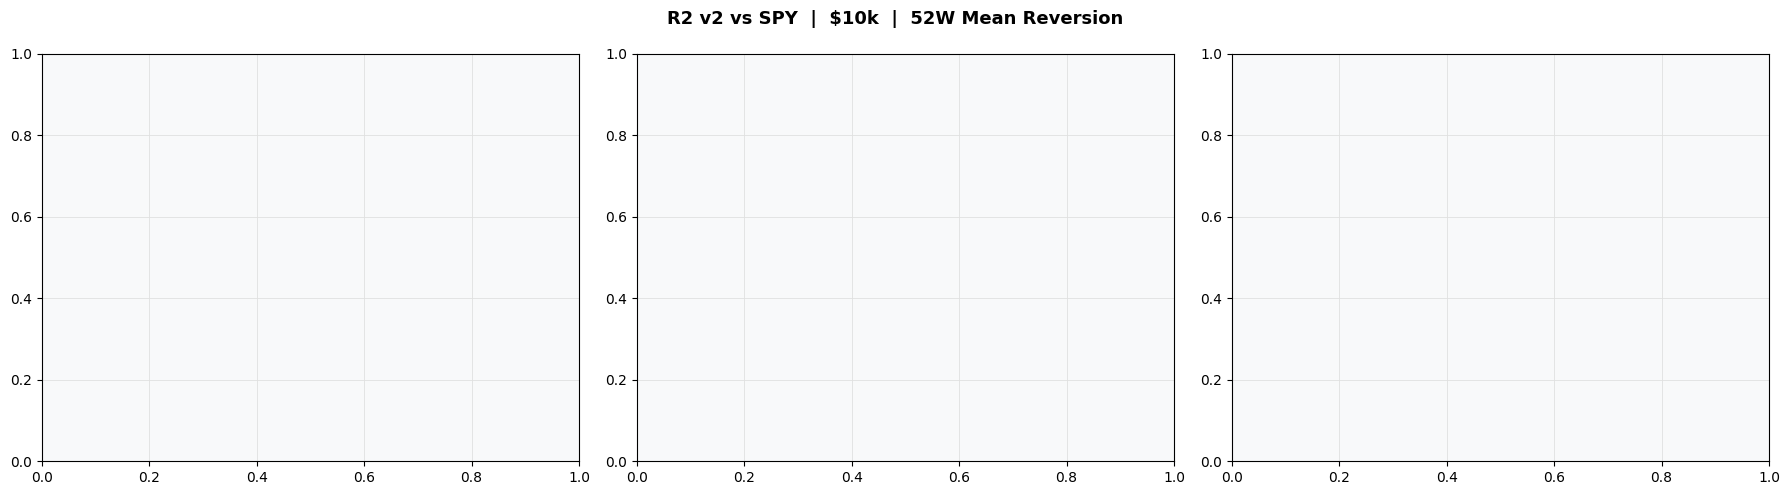

In [9]:
# Summary table + equity curves
rows = []
for lbl, r in r2v2_results.items():
    rows.append({
        'Horizon': lbl, 'Start': str(r['start'].date()), 'End': str(r['end'].date()),
        'Strat PnL ($)': f"${r['total_pnl']:+,.0f}",
        'Return': f"{r['total_ret']:+.1%}",
        'CAGR': f"{r['cagr']:+.1%}",
        'Sharpe': f"{r['sharpe']:.2f}",
        'MaxDD': f"{r['max_dd']:.1%}",
        'Trades': r['trades'], 'Win%': f"{r['win_rate']:.0%}",
        'SPY PnL ($)': f"${r['spy_pnl']:+,.0f}",
        'SPY Return': f"{r['spy_ret']:+.1%}",
        'SPY CAGR': f"{r['spy_cagr']:+.1%}",
        'SPY Sharpe': f"{r['spy_sharpe']:.2f}",
        'SPY MaxDD': f"{r['spy_dd']:.1%}",
    })
print('=== R2 v2 vs SPY on $10k ===')
display(pd.DataFrame(rows))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (lbl, r) in zip(axes, r2v2_results.items()):
    eq_n  = r['eq']      / r['eq'].iloc[0]      * 100
    spy_n = r['spy_seg'] / r['spy_seg'].iloc[0] * 100
    ax.plot(eq_n.index,  eq_n.values,  label='R2 v2', color='steelblue', lw=2)
    ax.plot(spy_n.index, spy_n.values, label='SPY',   color='#e06c00', lw=1.5, ls='--')
    ax.set_title(lbl, fontsize=12)
    ax.set_ylabel('Indexed (100 = start)')
    ax.legend()
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.suptitle('R2 v2 vs SPY  |  $10k  |  52W Mean Reversion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Cooldown Impact: v1 (no cooldown) vs v2 (with cooldown)

Side-by-side comparison of key metrics across all horizons.
v1 uses no re-entry cooldown; v2 adds a 20-day post-exit and 30-day post-stop cooldown.

In [10]:
# Cooldown comparison: v1 vs v2
comparison_rows = []
horizons = sorted(set(list(r2v1_results.keys()) + list(r2v2_results.keys())))
for h in horizons:
    r1 = r2v1_results.get(h)
    r2 = r2v2_results.get(h)
    if r1 is None or r2 is None:
        continue
    comparison_rows.append({
        'Horizon': h,
        'v1 Total Return': f"{r1['total_ret']:.2%}" if isinstance(r1['total_ret'], float) else r1['total_ret'],
        'v2 Total Return': f"{r2['total_ret']:.2%}" if isinstance(r2['total_ret'], float) else r2['total_ret'],
        'v1 Sharpe': f"{r1.get('sharpe', 0):.2f}",
        'v2 Sharpe': f"{r2.get('sharpe', 0):.2f}",
        'v1 Max DD': f"{r1.get('max_dd', 0):.2%}" if isinstance(r1.get('max_dd', 0), float) else str(r1.get('max_dd', 0)),
        'v2 Max DD': f"{r2.get('max_dd', 0):.2%}" if isinstance(r2.get('max_dd', 0), float) else str(r2.get('max_dd', 0)),
        'v1 Trades': r1.get('trades', '?'),
        'v2 Trades': r2.get('trades', '?'),
        'v1 Win Rate': f"{r1.get('win_rate', 0):.1%}" if isinstance(r1.get('win_rate', 0), float) else str(r1.get('win_rate', 0)),
        'v2 Win Rate': f"{r2.get('win_rate', 0):.1%}" if isinstance(r2.get('win_rate', 0), float) else str(r2.get('win_rate', 0)),
    })

if comparison_rows:
    comp_df = pd.DataFrame(comparison_rows)
    print("=== Cooldown Impact: v1 (none) vs v2 (20d / 30d-stop) ===\n")
    display(comp_df)

    # Equity curve overlay for longest horizon
    longest = horizons[-1]
    fig, ax = plt.subplots(figsize=(10, 5))
    r1 = r2v1_results[longest]
    r2 = r2v2_results[longest]
    eq1 = r1['eq'] / r1['eq'].iloc[0] * 100
    eq2 = r2['eq'] / r2['eq'].iloc[0] * 100
    ax.plot(eq1.index, eq1.values, label='v1 (no cooldown)', lw=1.8, alpha=0.8)
    ax.plot(eq2.index, eq2.values, label='v2 (with cooldown)', lw=1.8, alpha=0.8)
    ax.set_title(f'Equity Curves: v1 vs v2 ({longest})', fontsize=13)
    ax.set_ylabel('Indexed (100 = start)')
    ax.legend()
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No matching horizons between v1 and v2 results to compare.")

No matching horizons between v1 and v2 results to compare.


## Deployed Parameters

```python
# Live strategy: src/strategies/mean_reversion/high_pullback_reversion.py
# Config key:    strategies.mean_reversion.high_pullback_reversion
# Budget:        $10,000

ENTRY_DEPTH         = 0.40   # >= 40% below 52-week high
STOP_FROM_ENTRY     = 0.25   # -25% from entry price
EXIT_PULLBACK       = 0.25   # recovered to within 25% of 52-week high
MAX_HOLD_DAYS       = 63     # ~3 months
TOP_N               = 5      # max concurrent positions
COOLDOWN_DAYS       = 20     # days before re-entering same ticker
STOP_ENTRY_COOLDOWN = 30     # days before re-entering after stop-loss
SIZING              = pullback-weighted
```
